### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
drug = pd.read_csv('data/drugLibTrain_raw.tsv' , sep='\t')
drug.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [3]:
drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [4]:
# Ver columnas
print(drug.columns)

# Separar tipos
num_cols = drug.select_dtypes(include=['int64', 'float64']).columns
cat_cols = drug.select_dtypes(include=['object']).columns

# Ver número de categorías por columna categórica
for col in cat_cols:
    print(col, drug[col].nunique())

# Filtrar categóricas con menos de 10 categorías
cat_cols_filtered = [col for col in cat_cols if drug[col].nunique() < 10]

# Dataset final
drug_filtered = drug[list(num_cols) + cat_cols_filtered]

drug_filtered.head()

Index(['Unnamed: 0', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects',
       'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview'],
      dtype='object')
urlDrugName 502
effectiveness 5
sideEffects 5
condition 1426
benefitsReview 3031
sideEffectsReview 2813
commentsReview 3046


,Unnamed: 0,rating,effectiveness,sideEffects
0,2202,4,Highly Effective,Mild Side Effects
1,3117,1,Highly Effective,Severe Side Effects
2,1146,10,Highly Effective,No Side Effects
3,3947,3,Marginally Effective,Mild Side Effects
4,1951,2,Marginally Effective,Severe Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [5]:
drug_dummies = pd.get_dummies(drug_filtered, drop_first=True)

drug_dummies.head()

,Unnamed: 0,rating,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,2202,4,True,False,False,False,True,False,False,False
1,3117,1,True,False,False,False,False,False,False,True
2,1146,10,True,False,False,False,False,False,True,False
3,3947,3,False,False,True,False,True,False,False,False
4,1951,2,False,False,True,False,False,False,False,True


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(drug_dummies)

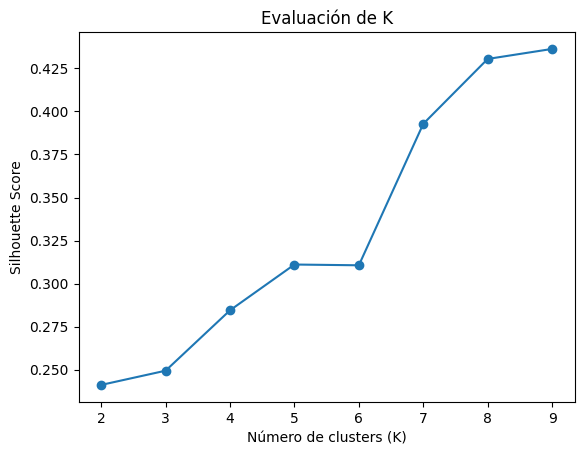

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Visualizar
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Evaluación de K')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

drug_dummies['cluster'] = clusters

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

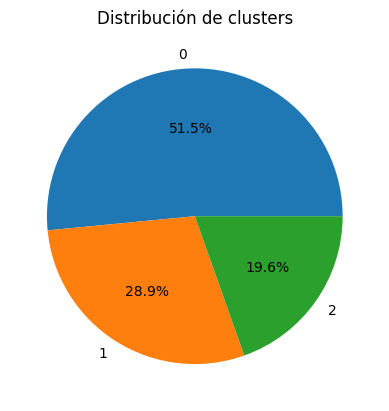

In [10]:
cluster_counts = drug_dummies['cluster'].value_counts()

plt.pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%')
plt.title('Distribución de clusters')
plt.show()